# Policy sweep results

Loads a run of `experiments/run_policy_sweep.py` and inspects it: which
policy wins each configuration, by how much, and whether the difference is
statistically real.

Nothing here re-runs anything -- it only reads `experiments/results/<run_name>/`.
See `experiments/README.md` for the column conventions.

**What a policy sweep measures.** For each configuration, every policy is run
over `n_reps` replications sharing one seed sequence (common random numbers),
so the policies face *identical* arrival streams. Differences are then paired
per seed, which removes most of the between-replication noise and is what
makes a modest difference detectable at 30 replications.

In [6]:
%load_ext autoreload
%autoreload 2

import json

import pandas as pd
import matplotlib.pyplot as plt

from experiments.core import DEFAULT_OUT_DIR, list_runs, load_meta
from experiments.policy_sweep import load_results, metric_table, metric_slug
from visualization.style import new_figure, style_axes, style_legend, palette

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Point this at a run

`RUN_NAME` is what you passed to `run_policy_sweep` (the `RUN_NAME` constant
in `experiments/run_policy_sweep.py`, `"policy_sweep"` by default).

In [7]:
print("runs on disk:", list_runs())

RUN_NAME = "power_sweep"   # <-- edit me

results = load_results(RUN_NAME)                    # one row per (config, policy)
comparisons = load_results(RUN_NAME, "comparisons")  # one row per (config, pair, metric)
wide = load_results(RUN_NAME, "results_wide")        # one row per config
reps = load_results(RUN_NAME, "replications")        # raw per-replication values

meta = load_meta(RUN_NAME)
print(f"{meta['n_configs']} config(s), {len(results)} policy run(s), "
      f"{len(reps)} episodes, {meta.get('total_runtime_s', float('nan')):.1f}s")
results.head()

runs on disk: ['power_sweep', 'policy_sweep', 'test']
11 config(s), 22 policy run(s), 660 episodes, 143.3s


,config_id,n_piles,n_connectors,n_modules,p_module,queue_capacity,mean_interarrival,max_time,warmup_period,flush_queue_at_warmup,...,util_rho_sim_ci_high,util_rho_sim_measured_mean,util_rho_sim_measured_ci_low,util_rho_sim_measured_ci_high,util_rho_theory_mean,util_rho_theory_ci_low,util_rho_theory_ci_high,util_rho_theory_measured_mean,util_rho_theory_measured_ci_low,util_rho_theory_measured_ci_high
0,0,1,2,6,25.0,1000,60.0,1440,360,False,...,0.252976,0.230238,0.213928,0.246547,0.237216,0.222350,0.252082,0.228435,0.212300,0.244570
1,0,1,2,6,25.0,1000,60.0,1440,360,False,...,0.311105,0.285330,0.266799,0.303861,0.292791,0.276207,0.309374,0.283916,0.266392,0.301440
2,1,1,2,6,25.0,1000,40.0,1440,360,False,...,0.394717,0.366926,0.348102,0.385750,0.370418,0.350217,0.390619,0.361221,0.342693,0.379749
3,1,1,2,6,25.0,1000,40.0,1440,360,False,...,0.460309,0.431633,0.411282,0.451984,0.432544,0.410536,0.454552,0.424607,0.404408,0.444807
4,2,1,2,6,25.0,1000,30.0,1440,360,False,...,0.547226,0.511809,0.487625,0.535993,0.517065,0.491172,0.542957,0.501302,0.475410,0.527195


## Pick the swept axis and the metric

`SWEPT` should be whatever you actually varied (the first key of `SWEEP` in
the runner script). `METRIC` is a human-readable name from
`DEFAULT_METRICS`; the full list is printed below.

`MEASURED=True` selects the post-warm-up counterpart of the metric, which is
identical to the whole-run one unless the scenario set a `warmup_period`.

In [8]:
# Every metric recorded, as the human-readable names metric_table expects.
metrics = sorted({c[:-5] for c in results.columns if c.endswith("_mean")})
print("metric column slugs:", metrics)

SWEPT = "mean_interarrival"   # the knob you varied
METRIC = "avg charge time"       # mean sojourn W = W_q + S
MEASURED = True              # True -> the post-warm-up counterpart

metric column slugs: ['average_l', 'average_l_measured', 'average_q', 'average_q_measured', 'avg_charge_time', 'avg_charge_time_measured', 'avg_sys_time', 'avg_sys_time_measured', 'avg_wait_time', 'avg_wait_time_measured', 'dropped_evs', 'dropped_evs_measured', 'finished_evs', 'finished_evs_measured', 'max_wait_time', 'max_wait_time_measured', 'total_energy_delivered_kwh', 'total_energy_delivered_kwh_measured', 'util_rho_sim', 'util_rho_sim_measured', 'util_rho_theory', 'util_rho_theory_measured']


## Headline: the metric by policy

Rows are configurations, columns are policies. Lower is better for the time
metrics.

In [9]:
metric_table(results, METRIC, measured=MEASURED, index=SWEPT).round(3)

policy,Prop,Constant
mean_interarrival,,
60.000000,27.835,34.771
40.000000,29.549,35.005
30.000000,30.775,34.956
24.000000,31.789,34.957
20.000000,32.965,35.035
17.142857,33.717,34.998
15.000000,34.115,35.094
13.333333,34.355,35.292
12.000000,34.338,35.224


## Plot: metric vs. the swept knob, with confidence bands

One line per policy, shaded to its confidence interval. Where the bands
overlap heavily, the per-policy CIs are not evidence of a difference -- read
the paired test in the next section instead, which is far more sensitive
because it removes the shared arrival-stream noise.

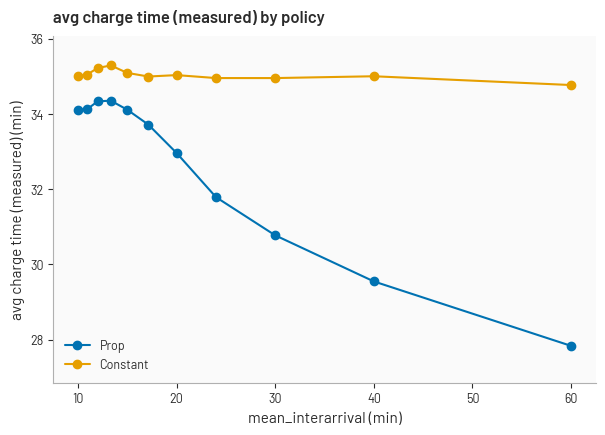

In [10]:
name = f"{METRIC} (measured)" if MEASURED else METRIC
slug = metric_slug(name)
policies = list(dict.fromkeys(results["policy"]))
colors = palette(len(policies))

fig, ax = new_figure(figsize=(7, 4.5))
for pol, color in zip(policies, colors):
    sub = results[results["policy"] == pol].sort_values(SWEPT)
    ax.plot(sub[SWEPT], sub[f"{slug}_mean"], marker="o", color=color, label=pol)
    ax.fill_between(sub[SWEPT], sub[f"{slug}_ci_low"], sub[f"{slug}_ci_high"],
                    color=color, alpha=0.0, linewidth=0)

ax.set_xlabel(SWEPT + " (min)")
#ax.set_xlim([10, 20])
ax.set_ylabel(f"{name} (min)" if "time" in name else name)
style_axes(ax, title=f"{name} by policy")
style_legend(ax)
plt.show()

## Grid: several metrics vs. the swept knob

Pick any number of metrics and get one subplot per metric, laid out in a
grid, all sharing the swept knob on the x-axis. A point gets a colored ring
around its marker wherever `GRID_PAIR`'s difference is significant at that
value of the swept knob -- see the `significant (...)` legend entry.

**The ring is a per-metric toggle.** Each entry in `METRICS_GRID` is either
a bare name (ring on, the default) or a `(name, False)` pair to turn the
ring off for just that metric -- useful when a metric's significance isn't
the point of showing it, or the ring pattern is so dense it just adds
clutter (as it was for the time metrics under heavy load, above).

Only that ONE pair is tested (matching the rest of this notebook, which
analyses one primary pair at a time -- there is no omnibus "do any of the
policies differ" test, only pairwise ones). With more than two policies in
the run, set `GRID_PAIR` explicitly to choose which comparison the rings
reflect; the other policies still plot, just without ring markers.

`SHARE_X` links every subplot's x-axis (same ticks; joint pan/zoom in an
interactive backend). `XLIM` is independent of that -- it forces the same
display range on every subplot regardless of `SHARE_X`, e.g. to zoom into
one region of the swept knob consistently across all metrics.

pair used for significance rings: 'FIFO|LSoCD'


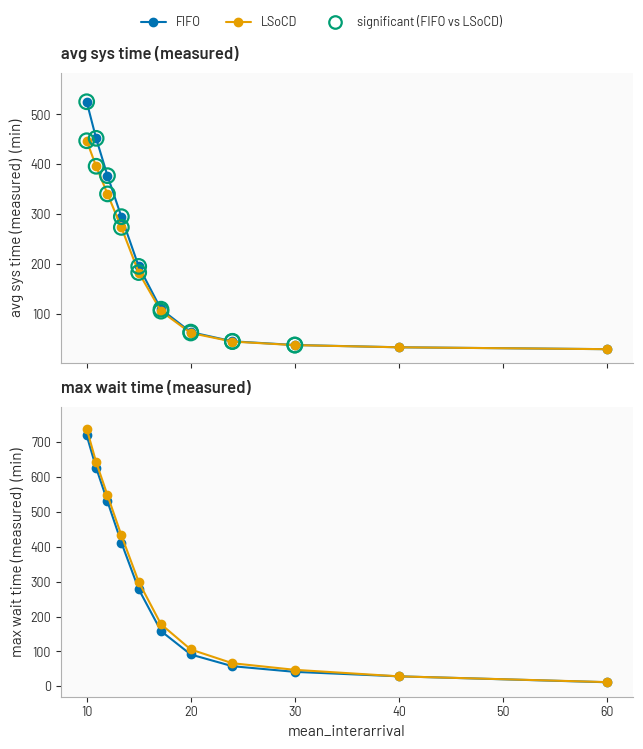

In [19]:
import math

from matplotlib.lines import Line2D

# --- what to plot -----------------------------------------------------------
# A bare name turns the significance ring ON (default); (name, False) turns
# it off for just that metric.
METRICS_GRID = [
    "avg sys time",
    ("max wait time", False)
    #("avg charge time", False),   # ring off -- see the markdown above
]
N_COLS = 1          # subplots per row

# --- the two toggles you asked for ------------------------------------------
SHARE_X = True       # link every subplot's x-axis (ticks, pan/zoom together)
XLIM = None          # e.g. (10, 30) to force the same x-range on every
                     # subplot regardless of SHARE_X; None leaves each auto

# --- which pair's significance gets a ring ----------------------------------
GRID_PAIR = None    # None -> first pair in `comparisons` (same rule as PAIR
                     # above); set e.g. "FIFO|LSoCD" to pick a specific one

pair = GRID_PAIR or (comparisons["pair"].iloc[0] if len(comparisons) else None)
sig_policies = set(pair.split("|")) if pair else set()
print(f"pair used for significance rings: {pair!r}")

policies = list(dict.fromkeys(results["policy"]))
colors = palette(len(policies))
sig_color = palette(3)[2]  # same "significant" ring color as the diff plot above

# Each entry is either "metric name" (ring on) or ("metric name", ring_on).
metric_labels = [e if isinstance(e, str) else e[0] for e in METRICS_GRID]
ring_on = [True if isinstance(e, str) else bool(e[1]) for e in METRICS_GRID]

names = [f"{m} (measured)" if MEASURED else m for m in metric_labels]
slugs = [metric_slug(n) for n in names]
missing = [m for m, s in zip(metric_labels, slugs) if f"{s}_mean" not in results.columns]
if missing:
    raise KeyError(f"Not in results: {missing}. Available: {metrics}")

n = len(METRICS_GRID)
ncols = min(N_COLS, n)
nrows = math.ceil(n / ncols)
fig, axes = new_figure(
    figsize=(6.5 * ncols, 3.6 * nrows), nrows=nrows, ncols=ncols,
    sharex=SHARE_X, squeeze=False,
)
axes_flat = axes.ravel()

# Did any subplot actually use the ring? Drives whether the legend gets a
# "significant" entry -- an entry for a ring nothing shows would be a lie.
any_ring_drawn = False

for i, (ax, name, slug, show_ring) in enumerate(zip(axes_flat, names, slugs, ring_on)):
    # Significant x-values for THIS metric, from the paired-comparison table.
    sig_x: set = set()
    if pair and show_ring:
        view_m = comparisons[
            (comparisons["pair"] == pair) & (comparisons["metric"] == name)
        ]
        sig_x = set(view_m.loc[view_m["significant"], SWEPT])

    for pol, color in zip(policies, colors):
        sub = results[results["policy"] == pol].sort_values(SWEPT)
        ax.plot(sub[SWEPT], sub[f"{slug}_mean"], marker="o", color=color, label=pol)
        ax.fill_between(sub[SWEPT], sub[f"{slug}_ci_low"], sub[f"{slug}_ci_high"],
                        color=color, alpha=0.0, linewidth=0)
        # Ring only the pair being tested, and only when this metric's own
        # toggle is on -- see the markdown above for both restrictions.
        if pol in sig_policies and sig_x:
            hit = sub[sub[SWEPT].isin(sig_x)]
            ax.scatter(hit[SWEPT], hit[f"{slug}_mean"], s=110, facecolors="none",
                      edgecolors=sig_color, linewidths=1.6, zorder=5)
            any_ring_drawn = any_ring_drawn or len(hit) > 0

    if XLIM is not None:
        ax.set_xlim(*XLIM)
    # With a shared x-axis, only the bottom-most subplot in each COLUMN needs
    # its own x tick labels/label -- y stays per-subplot regardless, since
    # each panel is a different metric with its own units. `i + ncols >= n`
    # is "nothing plotted directly below me", which is also correct for a
    # ragged last row (fewer metrics than nrows*ncols).
    is_col_bottom = (i + ncols) >= n
    if SHARE_X and not is_col_bottom:
        ax.tick_params(axis="x", labelbottom=False)
    else:
        ax.set_xlabel(SWEPT)
    ax.set_ylabel(f"{name}  (min)" if "time" in name else name)
    style_axes(ax, title=name)

# Hide any unused trailing axes when METRICS_GRID doesn't fill the grid.
for ax in axes_flat[n:]:
    ax.set_visible(False)

# One shared legend for the whole grid: a handle per policy, plus one for
# the significance ring -- omitted entirely if no subplot actually drew one.
handles = [Line2D([0], [0], color=c, marker="o", label=p)
          for p, c in zip(policies, colors)]
if any_ring_drawn:
    handles.append(Line2D(
        [0], [0], marker="o", linestyle="none", markerfacecolor="none",
        markeredgecolor=sig_color, markeredgewidth=1.6, markersize=9,
        label=f"significant ({pair.replace('|', ' vs ')})",
    ))
fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, 1.04),
          ncol=len(handles), frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

## The paired comparison: is the difference real?

This is the part a per-policy table cannot express. For each configuration
and metric, every policy pair gets the mean difference `A - B` and a
confidence interval on it, computed across paired replications.

**A CI that excludes zero means the difference is significant.** `winner`
names the policy with the lower mean (lower is better for the time metrics),
or `n.s.` when the interval straddles zero.

In [16]:
PAIR = comparisons["pair"].iloc[0]   # e.g. "FIFO|LSoCD"
print("pairs in this run:", sorted(comparisons["pair"].unique()))

view = comparisons[
    (comparisons["pair"] == PAIR)
    & (comparisons["metric"] == (f"{METRIC} (measured)" if MEASURED else METRIC))
].sort_values(SWEPT)

view[[SWEPT, "policy_a", "policy_b", "mean_a", "mean_b", "diff_mean",
      "diff_ci_low", "diff_ci_high", "significant", "winner"]].round(3)

pairs in this run: ['FIFO|LSoCD']


,mean_interarrival,policy_a,policy_b,mean_a,mean_b,diff_mean,diff_ci_low,diff_ci_high,significant,winner
234,10.000,FIFO,LSoCD,525.515,447.227,78.288,73.610,82.966,True,LSoCD
212,10.909,FIFO,LSoCD,452.058,395.950,56.107,51.799,60.416,True,LSoCD
190,12.000,FIFO,LSoCD,377.076,340.434,36.642,33.683,39.601,True,LSoCD
168,13.333,FIFO,LSoCD,294.739,273.204,21.535,18.939,24.132,True,LSoCD
146,15.000,FIFO,LSoCD,194.878,182.504,12.374,10.763,13.985,True,LSoCD
124,17.143,FIFO,LSoCD,108.973,104.957,4.016,3.235,4.797,True,LSoCD
102,20.000,FIFO,LSoCD,62.954,61.150,1.804,1.409,2.199,True,LSoCD
80,24.000,FIFO,LSoCD,44.478,43.917,0.561,0.405,0.716,True,LSoCD
58,30.000,FIFO,LSoCD,37.034,36.786,0.248,0.088,0.408,True,LSoCD
36,40.000,FIFO,LSoCD,32.466,32.439,0.027,-0.004,0.058,False,n.s.


### Difference plot

The paired difference with its confidence interval. Points whose error bar
crosses the dashed zero line are not statistically distinguishable; the
shaded side shows which policy the difference favours.

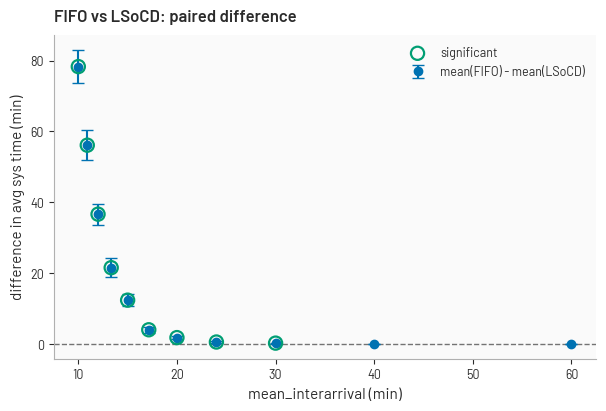

above zero -> LSoCD is lower (better); below zero -> FIFO is lower


In [20]:
a, b = PAIR.split("|")
fig, ax = new_figure(figsize=(7, 4.2))
colors = palette(3)

err_low = view["diff_mean"] - view["diff_ci_low"]
err_high = view["diff_ci_high"] - view["diff_mean"]
sig = view["significant"].astype(bool)

ax.errorbar(view[SWEPT], view["diff_mean"], yerr=[err_low, err_high],
            fmt="o", capsize=4, color=colors[0], zorder=3,
            label=f"mean({a}) - mean({b})")
# Mark the significant points so the eye finds them without reading the table.
ax.scatter(view.loc[sig, SWEPT], view.loc[sig, "diff_mean"],
           s=90, facecolors="none", edgecolors=colors[2], linewidths=1.6,
           zorder=4, label="significant")
ax.axhline(0.0, linestyle="--", linewidth=1.0, color="0.45", zorder=1)

ax.set_xlabel(SWEPT + " (min)")
ax.set_ylabel(f"difference in {METRIC} (min)")
style_axes(ax, title=f"{a} vs {b}: paired difference")
style_legend(ax)
plt.show()

print(f"above zero -> {b} is lower (better); below zero -> {a} is lower")

## Who won what, at a glance

`sign` is `-1` when the first policy of the pair is lower, `+1` when the
second is, `0` when the difference is not significant. Scanning a whole
sweep this way shows quickly whether one policy dominates or whether the
winner depends on the operating point.

In [28]:
signs = comparisons.pivot_table(
    index=[SWEPT, "pair"], columns="metric", values="sign", sort=False
)
# Keep the time metrics, which are the ones with a clear better direction.
keep = [c for c in signs.columns if "time" in c and "(measured)" not in c]
signs[keep].astype(int)

,metric,avg wait time,max wait time,avg charge time,avg sys time
mean_interarrival,pair,,,,
60.000000,FIFO|LSoCD,0,0,0,0
40.000000,FIFO|LSoCD,1,0,0,1
30.000000,FIFO|LSoCD,1,-1,0,1
24.000000,FIFO|LSoCD,1,-1,0,1
20.000000,FIFO|LSoCD,1,-1,0,1
17.142857,FIFO|LSoCD,1,-1,1,1
15.000000,FIFO|LSoCD,1,-1,1,1
13.333333,FIFO|LSoCD,1,-1,1,1
12.000000,FIFO|LSoCD,1,-1,1,1


## Raw replications

`replications.csv` holds every episode's own metric values, so anything
above can be recomputed at a different confidence level, or with a different
test, without re-simulating. Join back to configs on `config_id`.

In [29]:
per_seed = reps.pivot_table(
    index=["config_id", "seed"], columns="policy", values=METRIC
)
print(f"spread of {METRIC!r} across replications, config 0:")
per_seed.loc[0].describe().round(2)

spread of 'avg sys time' across replications, config 0:


policy,FIFO,LSoCD
count,30.00,30.00
mean,29.17,29.16
std,2.13,2.12
min,24.94,24.94
25%,27.90,27.90
50%,29.32,29.32
75%,30.81,30.81
max,32.42,32.42


## Notes

- **Common random numbers matter.** All policies in a config share the seed
  sequence, so `compare_policies` pairs them per replication. The paired CI
  is much tighter than the per-policy CIs suggest -- overlapping bands in
  the first plot do *not* imply "no difference".
- **`max_wait_used`** records what each policy's queue-wait override actually
  was. With `max_wait_from="FIFO"` the reference policy runs unconstrained
  and the others get its observed mean max wait times `max_wait_factor`, so
  the value is derived from the run rather than fixed by the config.
- **Lower is better** for the time metrics (`avg sys time`, `avg wait time`,
  `max wait time`, `avg charge time`) and for `dropped EVs`; higher is better
  for `finished EVs` and `total energy delivered (kWh)`. The `sign` column
  only encodes which mean is *lower*, so interpret it accordingly.
- This sweep is pure simulation. For how far a policy sits from the true
  optimum, see the objective sweep and `objective_sweep_results.ipynb`.